In [1]:
%pip install -r ../../requirements-offline.txt --quiet

/Users/utarn/projects/ml-metrology/.claude/worktrees/issue-33/.check-env/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


# Capstone Track B — ฟังเสียงเครื่องจักร 🔊

**M8 Capstone (Day 3 บ่าย) · Starter notebook — รันผ่านทั้งไฟล์ได้บนเครื่อง CPU ปกติ**

โจทย์: จำแนกเสียง 6 กลุ่ม "เครื่องจักร/เสียงโรงงาน" จาก **MFCC features + Random
Forest** (ทักษะ M4) — แล้วขยายด้วย feature engineering ของทีมเอง
เส้นทาง CNN บน spectrogram (M4-CNN) เป็นทางเลือกบน Kaggle — ดูหัวข้อ 6

โน้ตบุ๊กนี้คือ **กรอบเริ่มต้นที่รันจบแบบ end-to-end** — ทีมต่อยอดจากจุดที่ระบุ
(หัวข้อ 6) เช่นเพิ่ม class, เปลี่ยน feature, หรือใช้เสียงจริงที่ทีมอัดเอง

## Dataset / โมเดลที่ใช้ (citation + license)

- **ESC-50** — Piczak, K. J. (2015). "ESC: Dataset for Environmental Sound
  Classification", *Proc. ACM MM 2015* — **License: CC BY-NC 3.0 ⚠️
  ใช้ในห้องเรียนได้ แต่ห้ามใช้/แจกต่อเชิงพาณิชย์** — เตรียมไว้แล้วตาม
  README §เตรียมเครื่อง (โน้ตบุ๊ก M4 ใช้วิธีหาโฟลเดอร์เดียวกัน)
- **librosa** (ISC) · **scikit-learn** (BSD-3) · **RandomForestClassifier**
  — สะพานจากทักษะตารางของคอร์ส DS โดยตรง


## 1. ข้อมูล — ESC-50 subset: เฉพาะเสียง "เครื่องจักร"

ESC-50 มี 50 คลาส × 40 คลิป (5 วินาที/คลิป) แบ่ง fold ไว้ให้แล้ว
เราคัด 6 คลาสที่ใกล้โจทย์เสียงเครื่องจักรจริง = **240 คลิป** — เล็กพอให้จบ
บน CPU ในไม่กี่นาที ใหญ่พอให้ confusion matrix อ่านได้


In [2]:
import os  # noqa: E402
import zipfile  # noqa: E402
from pathlib import Path  # noqa: E402

SEED = 42


def repo_root() -> Path:
    """หา repo root โดยไล่ขึ้นจาก cwd."""
    for p in (Path.cwd(), *Path.cwd().parents):
        if (p / "requirements-offline.txt").exists():
            return p
    raise SystemExit(
        "ไม่พบ repo root — เปิด JupyterLab จาก repo root (uv run jupyter lab)"
    )


REPO = repo_root()


def find_esc50() -> Path | None:
    """ค้นหาโฟลเดอร์ ESC-50 ที่แตกไว้แล้วจากตำแหน่งที่รู้จัก (M4)."""
    env_dir = os.environ.get("ESC50_DIR")
    candidates = [
        Path(env_dir) if env_dir else None,
        REPO / "datasets" / "esc50" / "ESC-50-master",
        Path.home() / ".cache" / "esc50" / "ESC-50-master",
        Path.home() / "Downloads" / "ESC-50-master",
    ]
    for c in candidates:
        if c is not None and (c / "meta" / "esc50.csv").exists():
            print("พบ ESC-50 ที่:", c)
            return c
    return None


ESC50 = find_esc50()
if ESC50 is None:
    cache = Path.home() / ".cache" / "esc50"
    cache.mkdir(parents=True, exist_ok=True)
    zpath = cache / "esc50-master.zip"
    if not zpath.exists():
        print("ยังไม่มี ESC-50 — ดาวน์โหลดครั้งแรก ~600 MB")
        import requests

        url = "https://github.com/karoldvl/ESC-50/archive/master.zip"
        with requests.get(url, stream=True, timeout=120) as r:
            r.raise_for_status()
            with open(zpath, "wb") as f:
                for chunk in r.iter_content(chunk_size=1 << 20):
                    f.write(chunk)
    with zipfile.ZipFile(zpath) as zf:
        zf.extractall(cache)
    ESC50 = cache / "ESC-50-master"
print("repo root:", REPO)


พบ ESC-50 ที่: /Users/utarn/.cache/esc50/ESC-50-master
repo root: /Users/utarn/projects/ml-metrology/.claude/worktrees/issue-33


In [3]:
import pandas as pd  # noqa: E402

meta = pd.read_csv(ESC50 / "meta" / "esc50.csv")
MACHINE_CLASSES = [
    "engine", "train", "helicopter", "chainsaw",
    "vacuum_cleaner", "washing_machine",
]
sub = meta[meta["category"].isin(MACHINE_CLASSES)].reset_index(drop=True)
paths = [ESC50 / "audio" / f for f in sub["filename"]]
y_lab = sub["target"].to_numpy()
y_cat = sub["category"].to_numpy()
folds = sub["fold"].to_numpy()
id2cat = dict(zip(meta["target"], meta["category"]))
cats = sorted(set(y_lab))
print("จำนวนคลิป:", len(sub))
print(sub["category"].value_counts().to_string())


จำนวนคลิป: 240
category
vacuum_cleaner     40
chainsaw           40
train              40
helicopter         40
engine             40
washing_machine    40


1-18527-A-44.wav — เสียงเครื่องยนต์ 5 วินาที


/Users/utarn/projects/ml-metrology/.claude/worktrees/issue-33/.check-env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


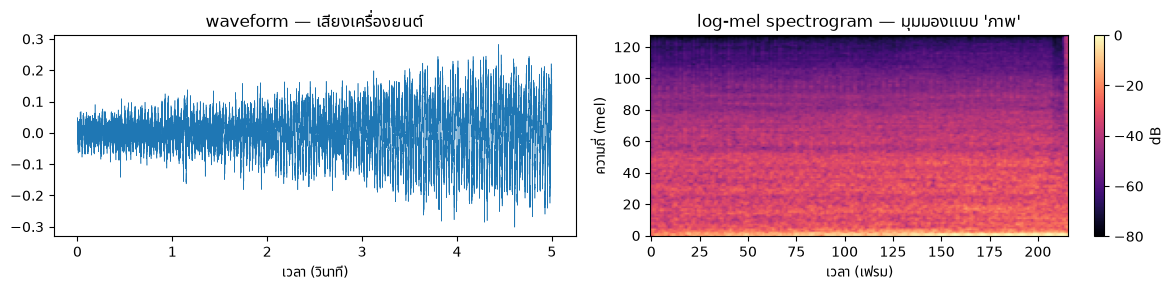

In [4]:
import librosa  # noqa: E402
import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
from IPython.display import Audio, display  # noqa: E402

plt.rcParams["font.family"] = ["DejaVu Sans", "Noto Sans Thai", "Tahoma"]
SR = 22050
EXAMPLE = sub.loc[sub["category"] == "engine", "filename"].iloc[0]
y, _ = librosa.load(ESC50 / "audio" / EXAMPLE, sr=SR, mono=True)
print(f"{EXAMPLE} — เสียงเครื่องยนต์ 5 วินาที")
display(Audio(data=y, rate=SR))

mel = librosa.power_to_db(
    librosa.feature.melspectrogram(y=y, sr=SR, n_mels=128),
    ref=np.max,
)
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(np.arange(len(y)) / SR, y, lw=0.4)
axes[0].set_title("waveform — เสียงเครื่องยนต์")
axes[0].set_xlabel("เวลา (วินาที)")
img = axes[1].imshow(mel, aspect="auto", origin="lower", cmap="magma")
axes[1].set_title("log-mel spectrogram — มุมมองแบบ 'ภาพ'")
axes[1].set_xlabel("เวลา (เฟรม)")
axes[1].set_ylabel("ความถี่ (mel)")
fig.colorbar(img, ax=axes[1], label="dB")
plt.tight_layout()
plt.show()


## 2. เสียง → ตัวเลข (ทักษะ M4) — MFCC 20 ตัว × (mean, std) = 40 feature

แต่ละคลิป 5 วินาที ≈ 110,000 ตัวเลขดิบ → บีบเหลือ 40 ตัวเลขต่อคลิป
แล้วงานที่เหลือคือ **ตาราง** ที่ทีมคุ้นเคยจากคอร์ส DS พอดี


In [5]:
from joblib import Parallel, delayed  # noqa: E402


def mfcc_row(path: Path) -> np.ndarray:
    """คลิปเดียว → เวกเตอร์ 40 ตัวเลข (mean+std ของ MFCC 20 ตัว)."""
    y, _ = librosa.load(path, sr=SR, mono=True)
    m = librosa.feature.mfcc(y=y, sr=SR, n_mfcc=20)
    return np.concatenate([m.mean(axis=1), m.std(axis=1)])


X = np.asarray(Parallel(n_jobs=-1)(delayed(mfcc_row)(p) for p in paths))
print("X:", X.shape, "→ ตาราง", len(sub), "แถว ×", X.shape[1], "feature")


X: (240, 40) → ตาราง 240 แถว × 40 feature


## 3. เทรน Random Forest — ใช้ fold split ที่ ESC-50 จัดไว้

เทรนด้วย fold 1–4 ทดสอบด้วย fold 5 (แบบเดียวกับ M4) — แล้วอ่าน confusion
matrix: **เสียงคู่ไหนที่โมเดลสับสน** คือหัวข้อที่ทีมวิเคราะห์ในการนำเสนอ


RF บน MFCC 40 — fold-5 accuracy = 0.479


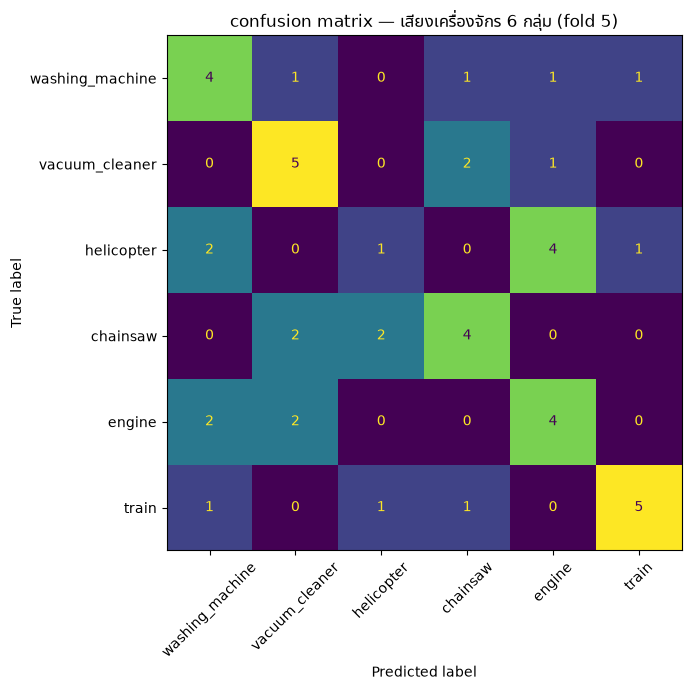

In [6]:
from sklearn.ensemble import RandomForestClassifier  # noqa: E402
from sklearn.metrics import (ConfusionMatrixDisplay,  # noqa: E402
                             accuracy_score)

TR, TE = folds != 5, folds == 5
rf = RandomForestClassifier(
    n_estimators=200, n_jobs=-1, random_state=SEED
).fit(X[TR], y_lab[TR])
pred = rf.predict(X[TE])
acc_rf = accuracy_score(y_lab[TE], pred)
print(f"RF บน MFCC 40 — fold-5 accuracy = {acc_rf:.3f}")

fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(
    y_lab[TE], pred, ax=ax, colorbar=False,
    display_labels=[id2cat[c] for c in cats], xticks_rotation=45,
)
ax.set_title("confusion matrix — เสียงเครื่องจักร 6 กลุ่ม (fold 5)")
plt.tight_layout()
plt.show()


## 4. Feature engineering — ทักษะ DS ที่ผสมเข้ามาตรง ๆ

MFCC เป็น feature "สำเร็จรูป" — โจทย์เสียงเครื่องจักรมักได้ประโยชน์จาก
**feature ที่คนออกแบบตามฟิสิกส์ของเสียง**: ความถี่ตัดกลาง (zero-crossing),
พลังงาน (RMS), ความถี่เด่น (spectral centroid) — ใส่เพิ่มแล้ววัดผลอีกครั้ง


In [7]:
def extra_row(path: Path) -> np.ndarray:
    """ZCR + RMS + spectral centroid → (mean, std) ต่อคลิป = 6 ค่า."""
    y, _ = librosa.load(path, sr=SR, mono=True)
    zcr = librosa.feature.zero_crossing_rate(y)
    rms = librosa.feature.rms(y=y)
    cen = librosa.feature.spectral_centroid(y=y, sr=SR)
    return np.concatenate([
        [zcr.mean(), zcr.std()],
        [rms.mean(), rms.std()],
        [cen.mean(), cen.std()],
    ])


X_extra = np.asarray(
    Parallel(n_jobs=-1)(delayed(extra_row)(p) for p in paths)
)
X2 = np.hstack([X, X_extra])
for name, F in [("MFCC (40)", X), ("MFCC + ZCR/RMS/centroid (46)", X2)]:
    rf2 = RandomForestClassifier(
        n_estimators=200, n_jobs=-1, random_state=SEED
    ).fit(F[TR], y_lab[TR])
    acc = accuracy_score(y_lab[TE], rf2.predict(F[TE]))
    print(f"{name}: fold-5 accuracy = {acc:.3f}")


MFCC (40): fold-5 accuracy = 0.479
MFCC + ZCR/RMS/centroid (46): fold-5 accuracy = 0.542


## 5. มุม anomaly แบบจิ๋ว — แนวคิด M6 ทำงานบน feature ตารางด้วย

โจทย์จริงของงานเมโทรโลยีคือ "เสียงผิดปกติ" ซึ่งมักไม่มีตัวอย่างให้ label —
แนวคิดเดียวกับ PatchCore ใช้ได้เลยบน MFCC ตาราง: สร้าง kNN จากเสียง
"ปกติ" แล้วให้คะแนน = ระยะไปเพื่อนบ้านที่ใกล้ที่สุด


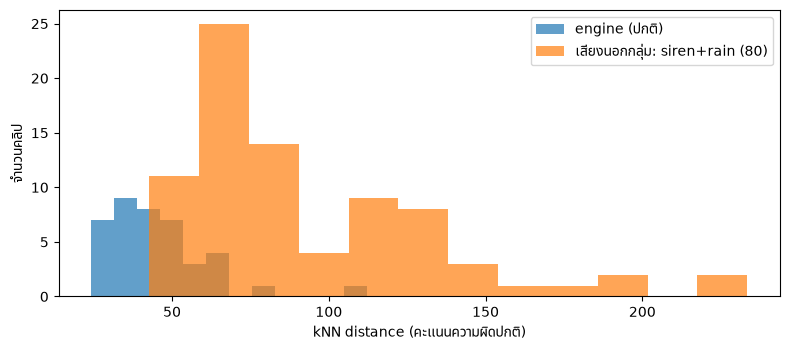

In [8]:
from sklearn.neighbors import NearestNeighbors  # noqa: E402

nn = NearestNeighbors(n_neighbors=3).fit(X[y_cat == "engine"])


def knn_score(F):
    """คะแนน anomaly = ระยะเฉลี่ยไป k เพื่อนบ้านในกลุ่ม 'ปกติ'."""
    d, _ = nn.kneighbors(F)
    return d.mean(axis=1)


foreign = meta[meta["category"].isin(["siren", "rain"])]
F_for = np.asarray(
    [mfcc_row(ESC50 / "audio" / f) for f in foreign["filename"]]
)
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.hist(knn_score(X[y_cat == "engine"]), bins=12, alpha=0.7,
        label="engine (ปกติ)")
ax.hist(knn_score(F_for), bins=12, alpha=0.7,
        label=f"เสียงนอกกลุ่ม: siren+rain ({len(F_for)})")
ax.set_xlabel("kNN distance (คะแนนความผิดปกติ)")
ax.set_ylabel("จำนวนคลิป")
ax.legend()
plt.tight_layout()
plt.show()


## 6. ทางทีมต่อยอด — รวมถึง "ข้อมูลจริงของทีม" (bring-your-own)

**ทางเลือก CNN บน spectrogram (Kaggle GPU):** ตามแบบ
`../../module4_esc50_cnn/` — เทรน CNN จากศูนย์บนภาพ log-mel ของคลิปชุดเดิม
(นาทีล้านของ CPU กลายเป็นนาทีบน T4) — ทีมไหนอยากเทียบ "ตาราง vs CNN"
ให้รัน starter นี้บนเครื่อง + CNN บน Kaggle แล้วนำ accuracy มารวมตารางเดียว

**ใช้เสียงจริงของทีม:** อัดด้วยมือถือก็พอ — เก็บไว้ที่ `data/capstone_b/
<ชื่อสภาพ>/*.wav` (gitignored):

- คลิป 5 วินาที × **≥ 20 คลิปต่อสภาพ** (ปกติ / คล้อยชิ้น / หลวม / ไม่มีน้ำมัน…)
- อัดหลาย **เซสชัน** (วันเวลาต่างกัน) แล้วแบ่ง train/test **ที่ระดับเซสชัน** —
  คลิปจากเซสชันเดียวใกล้เคียงกันจนวัดผลสวยหลอก
- ไมค์/ระยะ/ความเร็วเครื่องให้คงที่เท่าที่ทำได้ — แล้วจดเงื่อนไขไว้พูดตอนนำเสนอ
- โหลดด้วย `librosa.load(path, sr=SR, mono=True)` ตรง ๆ — โค้ดชุดเดิมใช้ต่อได้

**ขยายคุณภาพ:** เพิ่ม MFCC delta (M4) · เปลี่ยน n_mfcc · ลอง kNN anomaly
กับเสียงจริงของทีม (ปกติ vs ผิดปกติ) แล้วรายงาน AUC

## สิ่งที่ผลงานต้องมี (ตรวจด้วย rubric)

1. โมเดลอย่างน้อยหนึ่งชุด feature เทรนด้วยมือของทีม (Restart & Run All ผ่าน)
2. การวัดผลซื่อสัตย์ตาม split ที่อธิบายได้ (fold ของ ESC-50 หรือเซสชันของทีม)
3. Confusion matrix + การวิเคราะห์คู่สับสน (เสียงไหนหน้าตาคล้ายกันเพราะอะไร)
4. ย่อหน้าข้อจำกัด: สภาพเสียงที่โมเดลยังจับไม่ได้ + สิ่งที่จะทำต่อ
5. สไลด์ 10 นาที — โครงตาม `rubric.md`
